In [1]:
!pip install Pillow

In [10]:
import os, random
from PIL import Image, ImageEnhance

classes = ['ae', 'ai', 'canva', 'figma', 'inkscape', 'lr', 'paint', 'photoshop', 'procreate', 'sketch']
base_dir = 'dataset/base_images'
output_dir = 'dataset_ready'
target_count = 100
target_size = (64, 64)

for cls in classes:
    cls_path = os.path.join(base_dir, cls)
    if not os.path.isdir(cls_path):
        print(f"Папка {cls_path} не найдена, пропускаем.")
        continue
    
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    if not images:
        print(f"В папке {cls_path} нет изображений!")
        continue
    
    out_cls = os.path.join(output_dir, cls)
    os.makedirs(out_cls, exist_ok=True)
    
    for i in range(target_count):
        src_name = random.choice(images)
        img = Image.open(os.path.join(cls_path, src_name)).convert('RGB')
        img = img.resize(target_size, Image.Resampling.LANCZOS)
        
        if i == 0:
            new_img = img
        else:
            angle = random.randint(-30, 30)
            img = img.rotate(angle, expand=False, fillcolor=(255,255,255))
            
            enh = ImageEnhance.Brightness(img)
            img = enh.enhance(random.uniform(0.7, 1.3))
            
            enh = ImageEnhance.Contrast(img)
            img = enh.enhance(random.uniform(0.7, 1.3))
            
            w, h = img.size
            shift_x = random.randint(-5, 5)
            shift_y = random.randint(-5, 5)
            img = img.transform(img.size, Image.AFFINE, (1,0,shift_x,0,1,shift_y), fillcolor=(255,255,255))
            new_img = img
        
        save_name = f"{cls}_{i:03d}.png"
        new_img.save(os.path.join(out_cls, save_name), 'PNG')
    
    print(f"{cls}: создано {target_count} изображений")

print("\n✅ Готово! Проверьте папку dataset_ready.")

ae: создано 100 изображений
ai: создано 100 изображений
canva: создано 100 изображений
figma: создано 100 изображений
inkscape: создано 100 изображений
lr: создано 100 изображений
paint: создано 100 изображений
photoshop: создано 100 изображений
procreate: создано 100 изображений
sketch: создано 100 изображений

✅ Готово! Проверьте папку dataset_ready.


In [11]:
import pandas as pd

data = []
for cls in classes:
    cls_dir = os.path.join('dataset_ready', cls)
    if os.path.exists(cls_dir):
        for fname in os.listdir(cls_dir):
            if fname.endswith('.png'):
                data.append({'filename': fname, 'class': cls})

df = pd.DataFrame(data)
df.to_csv('annotations.csv', index=False)
print(f"Файл annotations.csv создан. Записей: {len(df)}")
df.head()

Файл annotations.csv создан. Записей: 1000


,filename,class
0,ae_000.png,ae
1,ae_001.png,ae
2,ae_002.png,ae
3,ae_003.png,ae
4,ae_004.png,ae


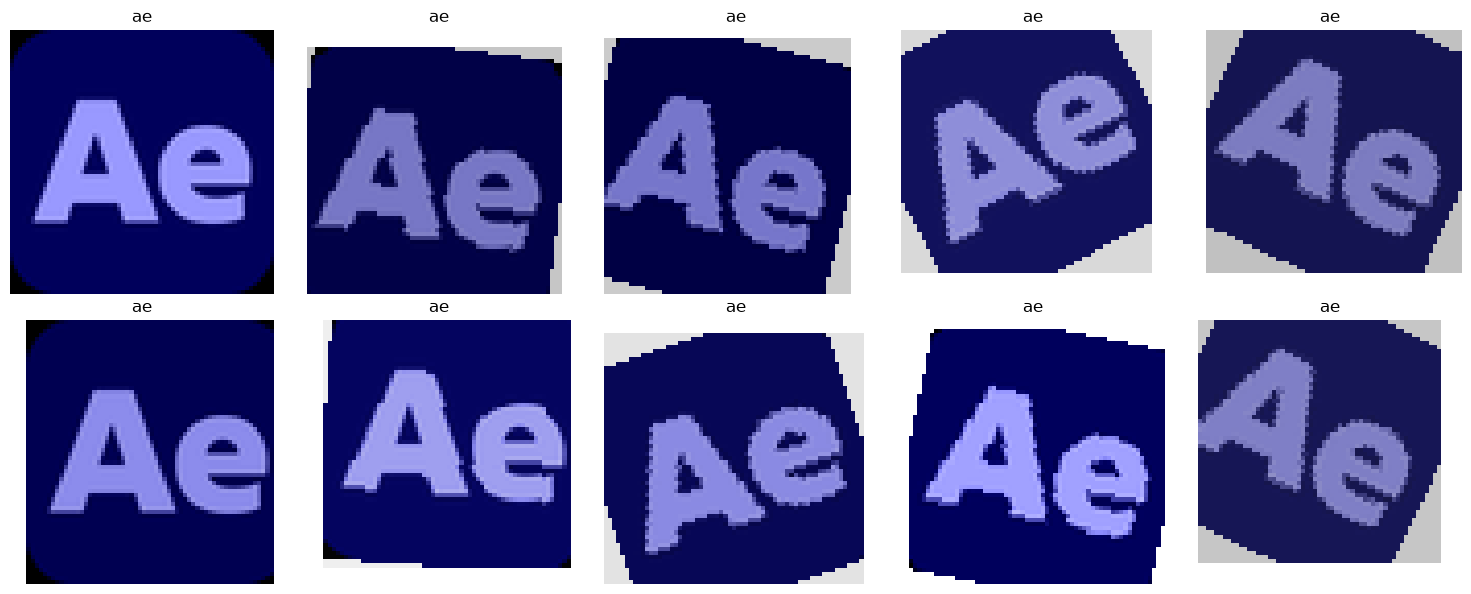

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(df):
        row = df.iloc[i]
        img_path = os.path.join('dataset_ready', row['class'], row['filename'])
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(row['class'])
        ax.axis('off')
plt.tight_layout()
plt.show()

Объект датасета:Логотипы графических редакторов
Количество классов: 10
Количество объектов: в каждом классе 100
Общий объем датасета: 1000 изображений
Разрешение изображений:	64×64 пикселя
Формат файла изображения: png
Способ аннотации:Многоклассовая классификация
Формат файла аннотации:	CSV (annotations.csv)
Метод аугментации:Повороты, яркость, контраст, сдвиги

In [14]:
import os
print(os.getcwd())
print(os.path.abspath('annotations.csv'))

C:\Users\User
C:\Users\User\annotations.csv


In [15]:
!pip install kaggle


   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ------------- -------------------------- 1/3 [jupytext]
   -------------------------- ------------- 2/3 [kaggle]
   ---------------------------------------- 3/3 [kaggle]



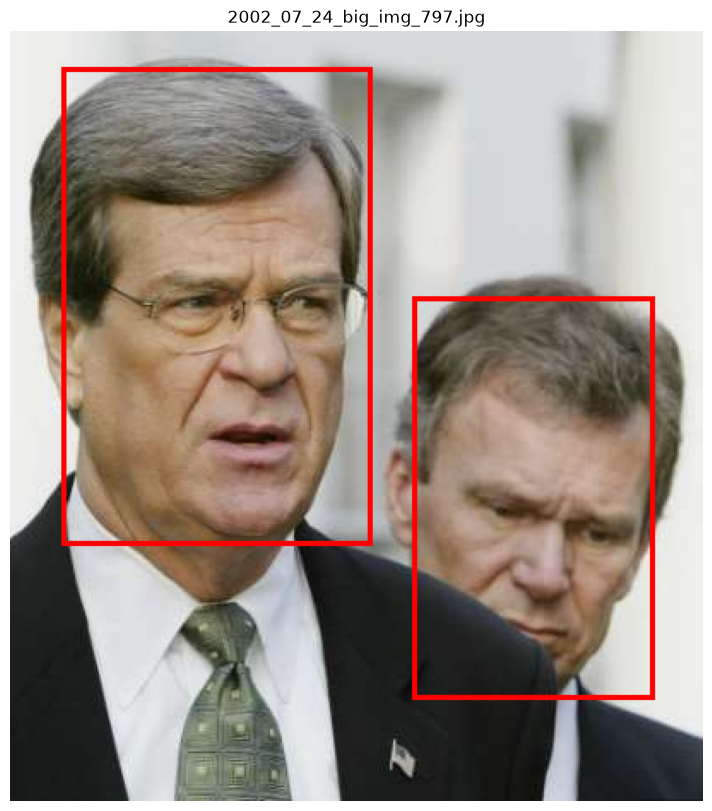

In [3]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

img_dir = 'data/fddb/images/train'
label_dir = 'data/fddb/labels/train'

all_images = os.listdir(img_dir)
img_name = random.choice(all_images)
img_path = os.path.join(img_dir, img_name)

label_name = os.path.splitext(img_name)[0] + '.txt'
label_path = os.path.join(label_dir, label_name)

img = Image.open(img_path).convert('RGB')
w, h = img.size
draw = ImageDraw.Draw(img)

if os.path.exists(label_path):
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, xc, yc, bw, bh = parts
            xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
            x1 = (xc - bw/2) * w
            y1 = (yc - bh/2) * h
            x2 = (xc + bw/2) * w
            y2 = (yc + bh/2) * h
            draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
else:
    print("Файл разметки не найден:", label_path)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title(img_name)
plt.axis('off')
plt.show()

In [4]:
!pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 3.8 MB/s eta 0:00:12
   --- ------------------------------------ 4.2/44.0 MB 15.0 MB/s eta 0:00:03
   ------- -------------------------------- 7.9/44.0 MB 16.0 MB/s eta 0:00:03
   ---------- ----------------------------- 11.3/44.0 MB 16.6 MB/s eta 0:00:02
   -------------- ------------------------- 15.7/44.0 MB 16.6 MB/s eta 0:00:02
   ----------------- ---------------------- 19.4/44.0 MB 16.9 MB/s eta 0:00:02
   -------------------- ------------------- 22.0/44.0 MB 16.0 MB/s eta 0:00:02
   ----------------------- ---------------- 26.0/44.0 MB 16.3 MB/s eta 0:00:02
   --------------------------- ------------ 30.4/44.0 MB 16.8 MB/s eta 0:00:01
   ------------------------------- -------- 34.6/44.0 MB 17.1 MB/s eta 0:00:01
   ---------------------------------- ----- 38.3/44.0 MB 17.2 MB/s eta 0:00:01
   -------------------------------------- - 42.2/44.0 MB 17.4 MB/

In [4]:
from PIL import Image

image_name = 'myface.jpg'
image_path = f'data/fddb/images/train/{image_name}'

x1, y1 = 165, 532
x2, y2 = 777, 1264

img = Image.open(image_path)
img_w, img_h = img.size
print(f"Размер фото: {img_w} x {img_h} пикселей")

w_box = x2 - x1
h_box = y2 - y1
x_center = (x1 + w_box / 2) / img_w
y_center = (y1 + h_box / 2) / img_h
width_norm = w_box / img_w
height_norm = h_box / img_h

line = f"0 {x_center:.6f} {y_center:.6f} {width_norm:.6f} {height_norm:.6f}"
print("Строка для файла разметки:")
print(line)

label_path = f'data/fddb/labels/train/{image_name.rsplit(".", 1)[0]}.txt'
with open(label_path, 'w') as f:
    f.write(line + '\n')
print(f"\n✅ Файл {label_path} создан!")

Размер фото: 960 x 1280 пикселей
Строка для файла разметки:
0 0.490625 0.701562 0.637500 0.571875

✅ Файл data/fddb/labels/train/myface.txt создан!


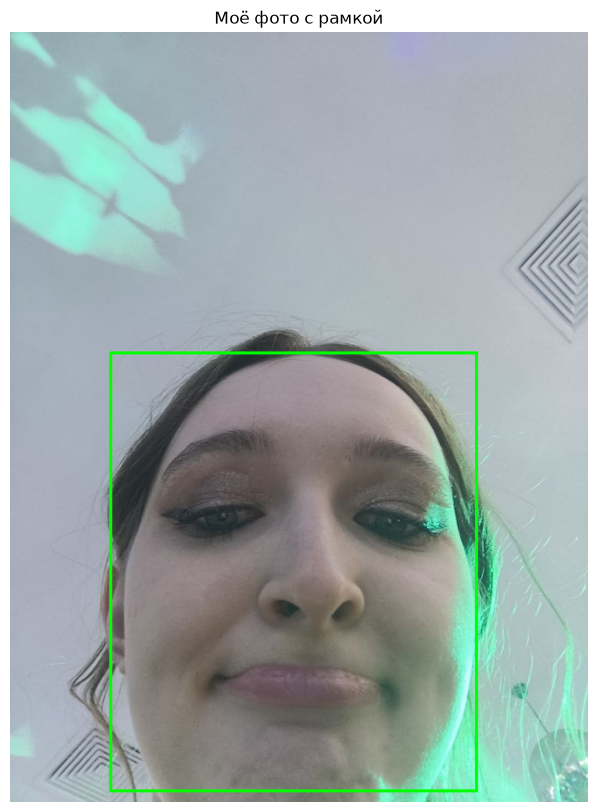

In [5]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

img = Image.open(image_path).convert('RGB')
w, h = img.size
draw = ImageDraw.Draw(img)

with open(label_path) as f:
    _, xc, yc, bw, bh = map(float, f.read().strip().split())

x1 = (xc - bw/2) * w
y1 = (yc - bh/2) * h
x2 = (xc + bw/2) * w
y2 = (yc + bh/2) * h

draw.rectangle([x1, y1, x2, y2], outline='lime', width=5)

plt.figure(figsize=(8, 10))
plt.imshow(img)
plt.title("Моё фото с рамкой")
plt.axis('off')
plt.show()